# FInal Project

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

## Packages

In [3]:
library(fst)
library(highfrequency)
library(xts)
library(rugarch)
library(forecast)
library(zoo)

Warning message:
"package 'fst' was built under R version 4.5.3"
Warning message:
"package 'highfrequency' was built under R version 4.5.3"
Warning message:
"package 'xts' was built under R version 4.5.2"
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Warning message:
"package 'rugarch' was built under R version 4.5.2"
Loading required package: parallel

Warning message:
"package 'forecast' was built under R version 4.5.2"


## Loading Data

In [4]:
data <- load("data_project/30.RData")
head(data)
asset_data <- get(data[1])
head(asset_data)

[1] "amt"

                     ret          RV        RV_p        RV_n           RS
2010-01-05  0.0002304634 0.011009479 0.009259483 0.005955720  1.350981427
2010-01-06  0.0168678327 0.011202805 0.008230314 0.007600314 -0.216028901
2010-01-07  0.0042856864 0.011699048 0.008224708 0.008319971 -0.006426756
2010-01-08 -0.0011261662 0.009363287 0.007205883 0.005978829  0.753857266
2010-01-11  0.0109791088 0.011245783 0.006254063 0.009346354 -0.759894442
2010-01-12 -0.0252775180 0.011362306 0.006760609 0.009132151 -0.795626739
                 RK
2010-01-05 5.926201
2010-01-06 6.845365
2010-01-07 4.509419
2010-01-08 6.858052
2010-01-11 5.162329
2010-01-12 4.448177

## Exploratory analysis

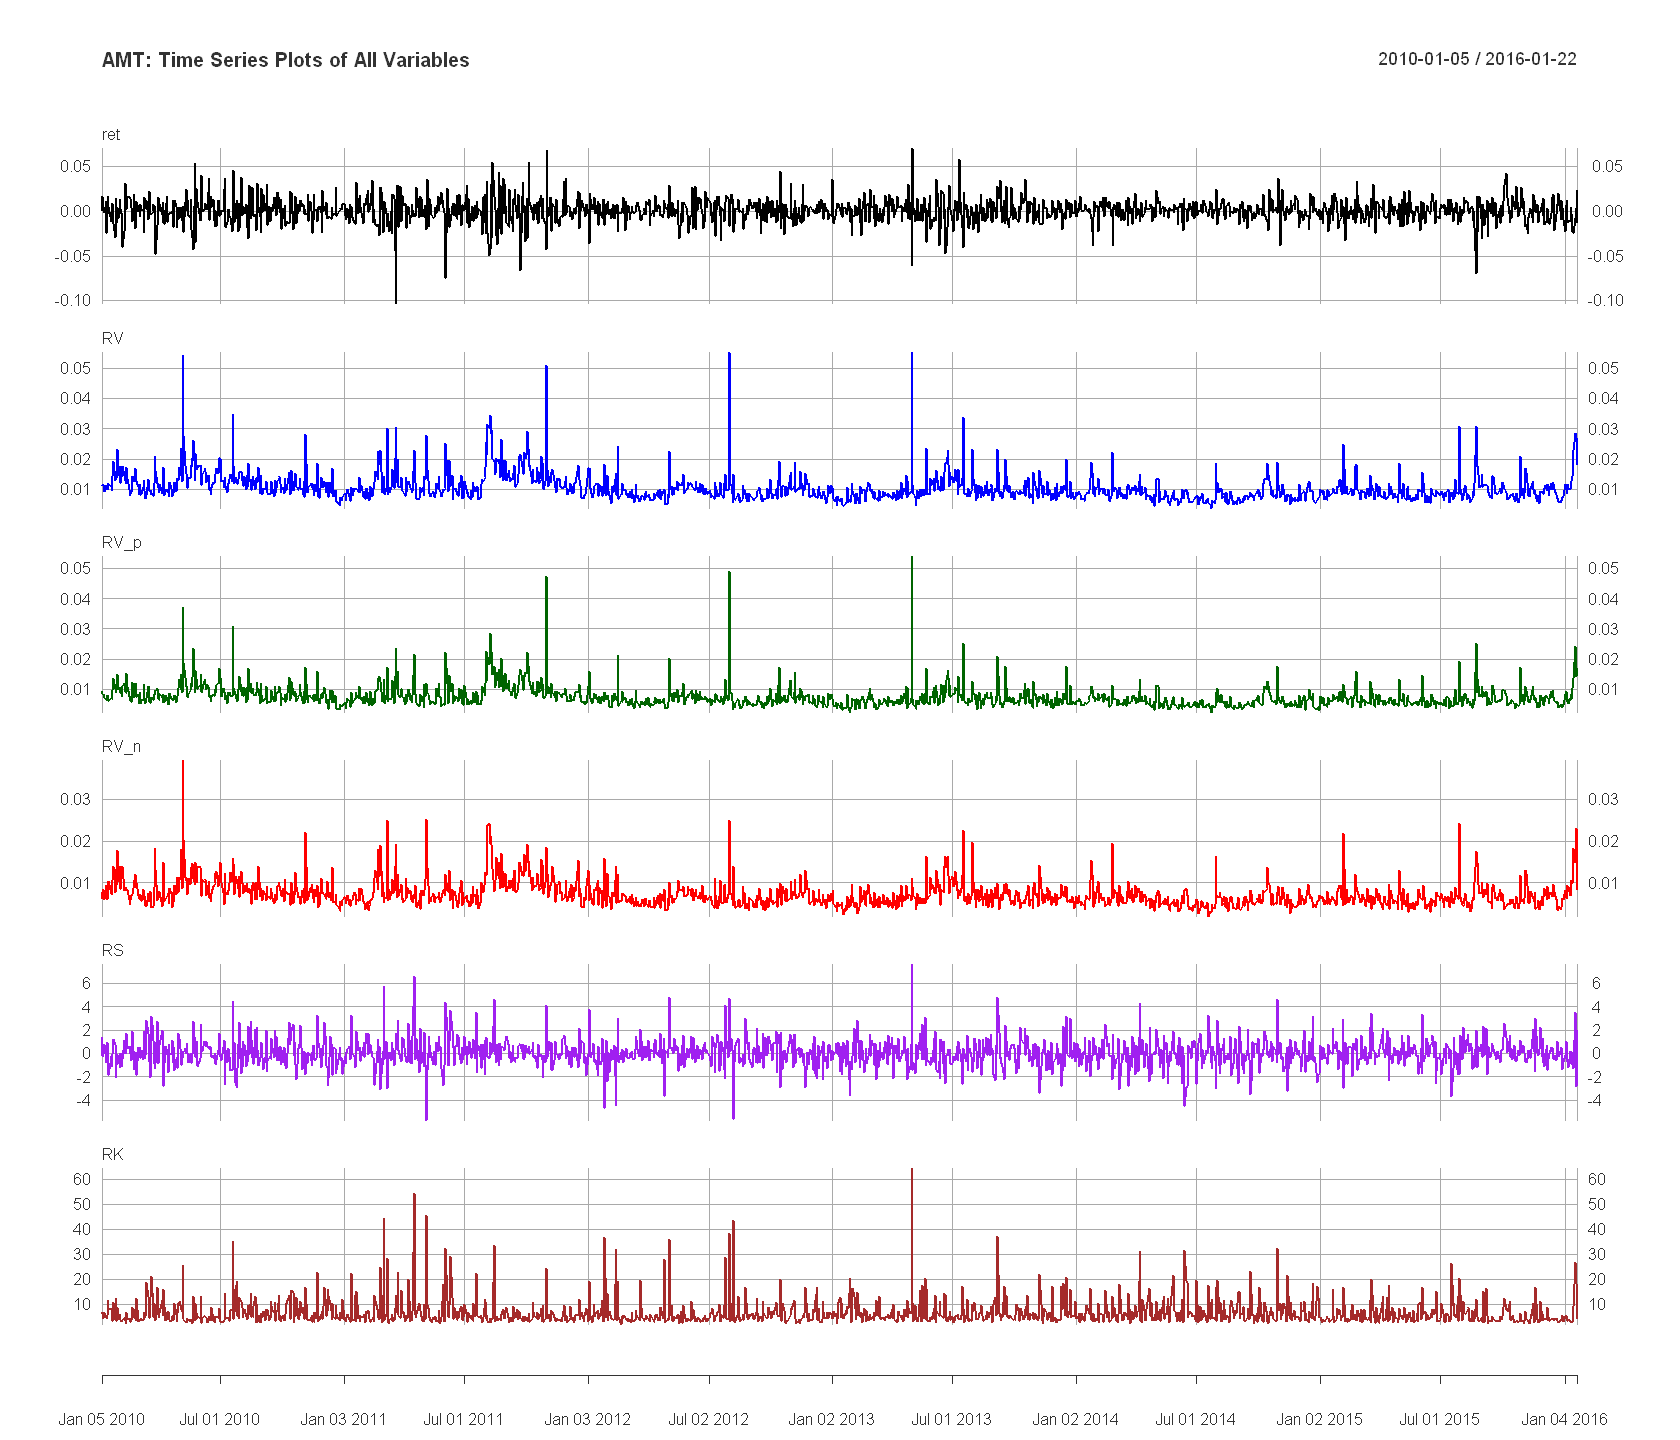

In [5]:
options(repr.plot.width = 14, repr.plot.height = 12)
plot.xts(asset_data, 
         multi.panel = TRUE, 
         yaxis.same = FALSE,
         col = c("black", "blue", "darkgreen", "red", "purple", "brown"),
         main = "AMT: Time Series Plots of All Variables")

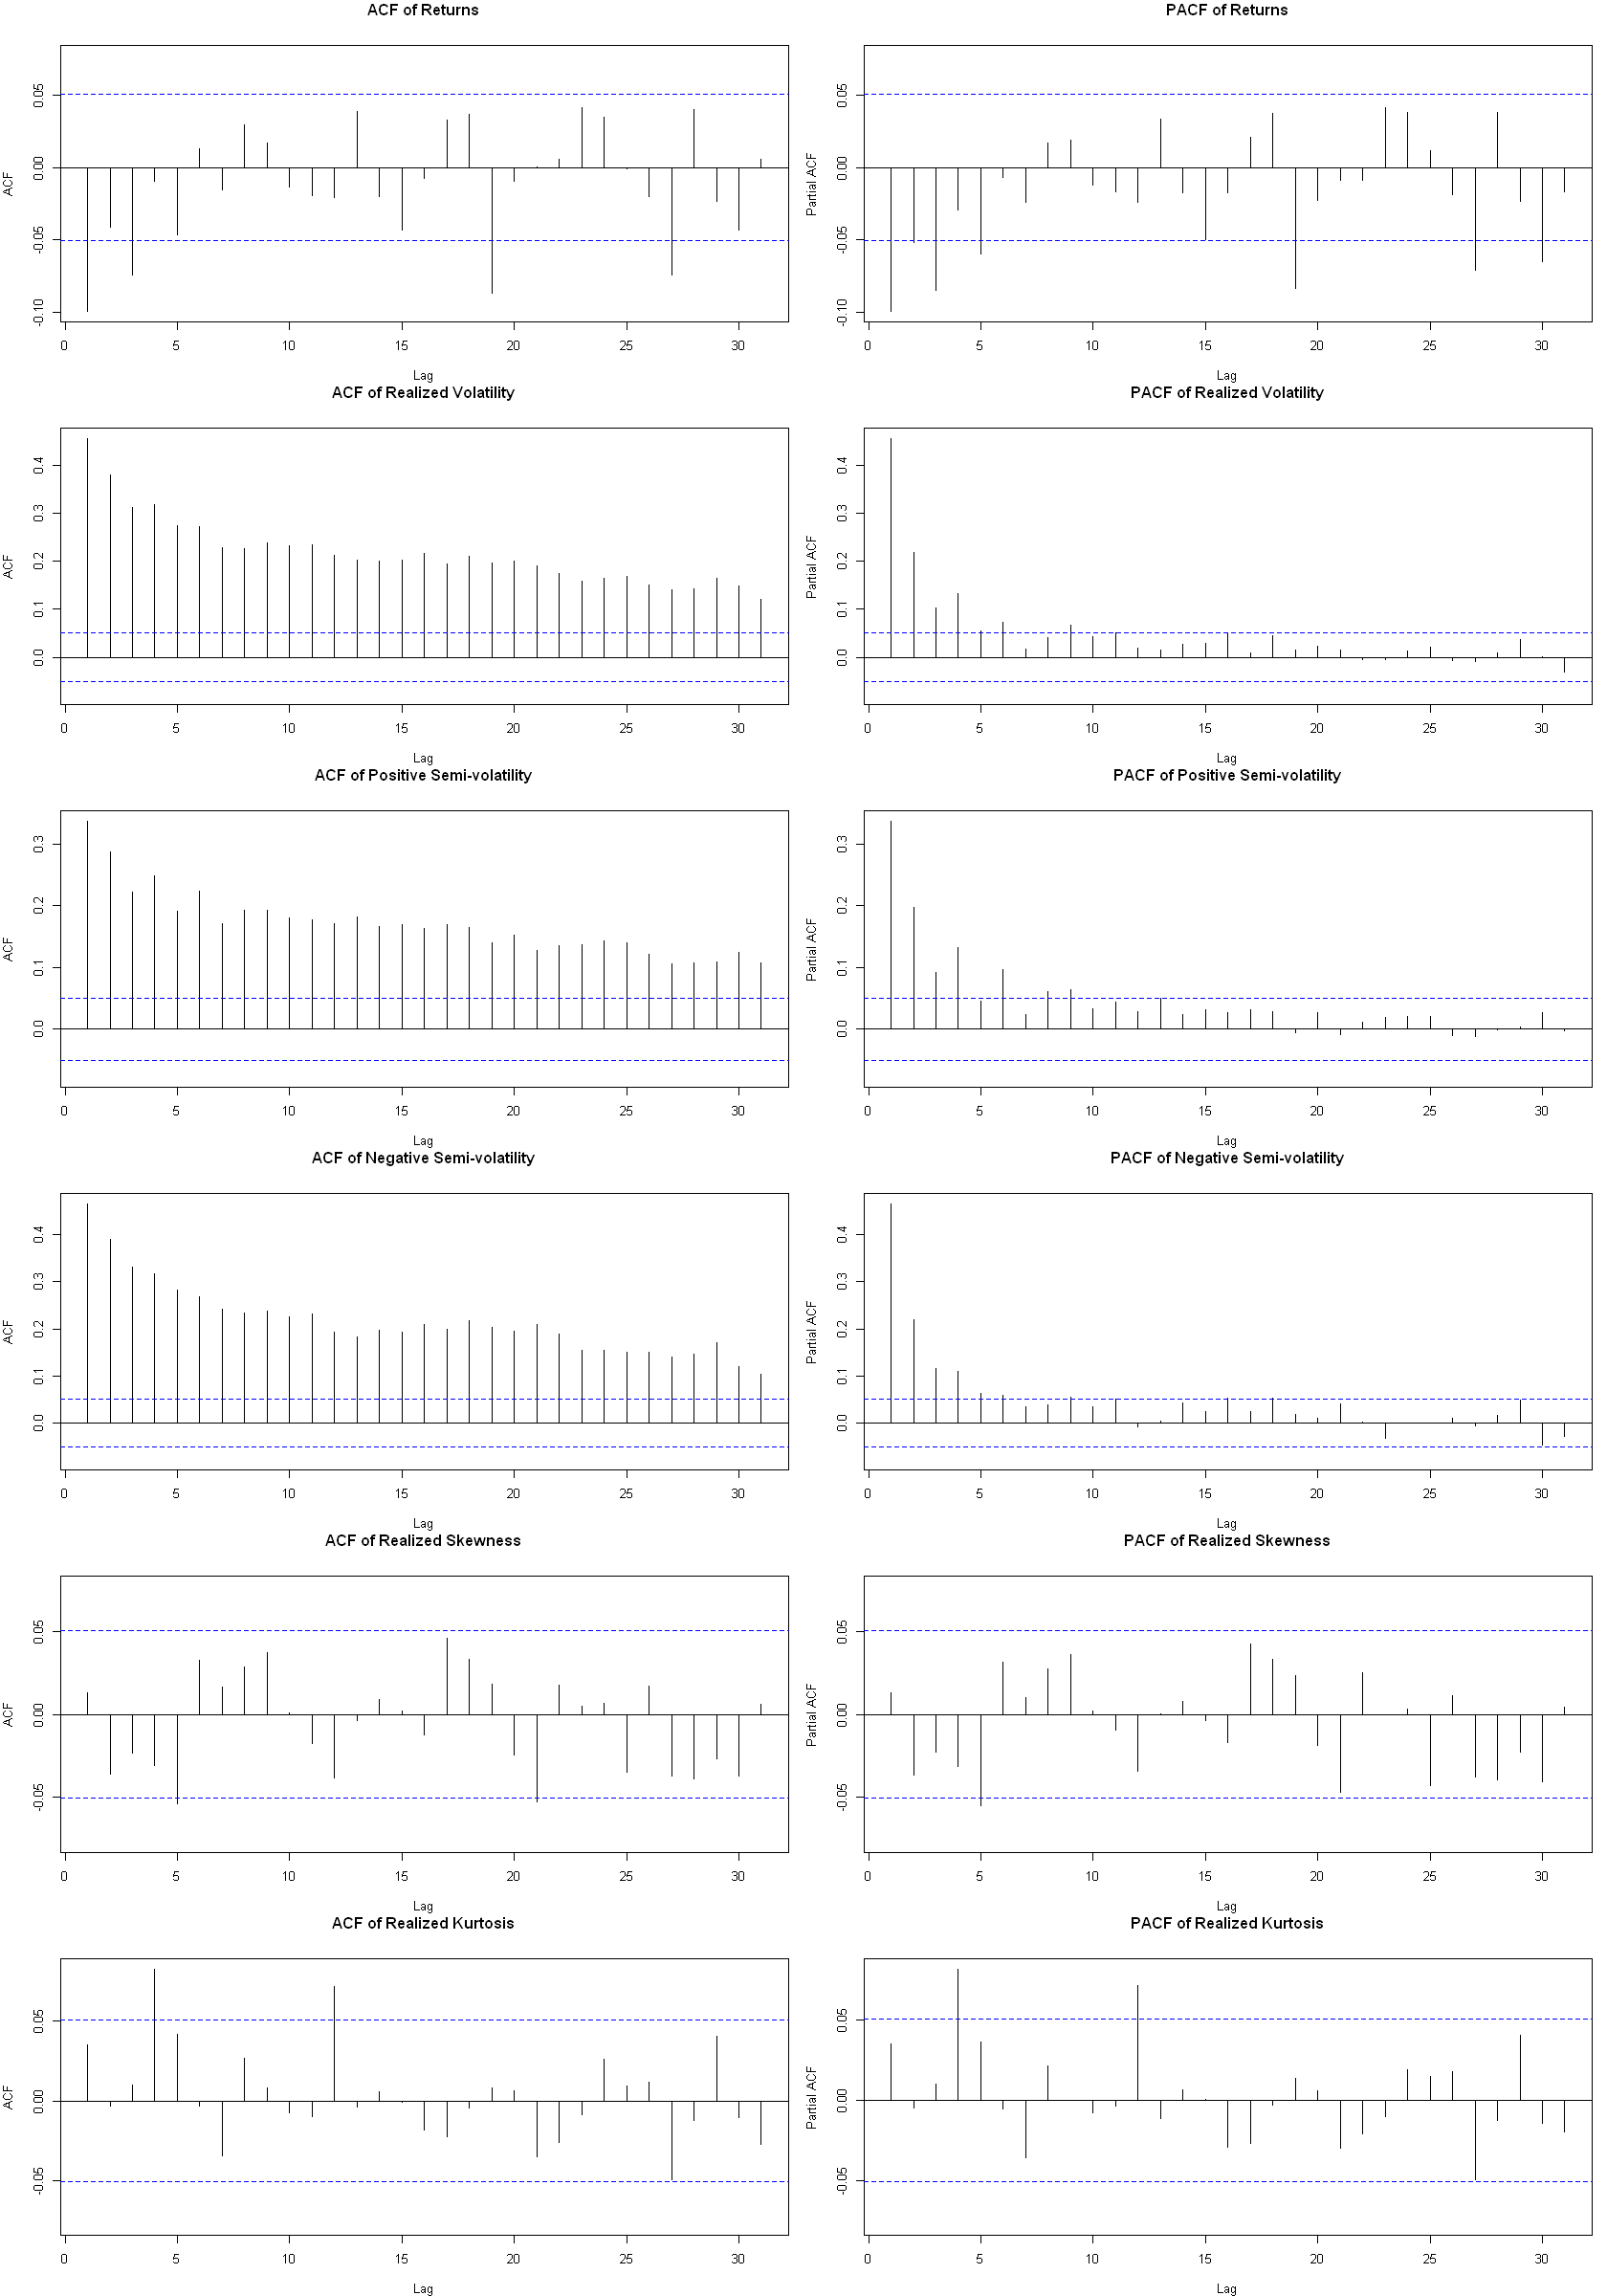

In [6]:
options(repr.plot.width = 14, repr.plot.height = 20)
par(mfrow = c(6, 2), mar = c(4, 4, 3, 1))

#ret
Acf(asset_data$ret, main = "ACF of Returns")
Pacf(asset_data$ret, main = "PACF of Returns")

#rv
Acf(asset_data$RV, main = "ACF of Realized Volatility")
Pacf(asset_data$RV, main = "PACF of Realized Volatility")

#rvp
Acf(asset_data$RV_p, main = "ACF of Positive Semi-volatility")
Pacf(asset_data$RV_p, main = "PACF of Positive Semi-volatility")

#rvn
Acf(asset_data$RV_n, main = "ACF of Negative Semi-volatility")
Pacf(asset_data$RV_n, main = "PACF of Negative Semi-volatility")
#rs
Acf(asset_data$RS, main = "ACF of Realized Skewness")
Pacf(asset_data$RS, main = "PACF of Realized Skewness")
#rk
Acf(asset_data$RK, main = "ACF of Realized Kurtosis")
Pacf(asset_data$RK, main = "PACF of Realized Kurtosis")


par(mfrow = c(1, 1))

## In-Sample models

### data preparation

In [7]:
#rv lagged daily
RV_1 <- lag(asset_data$RV, 1)
#rolling weekly and monthly averages
RV_5 <- rollmean(RV_1, k = 5, fill = NA, align = "right")
RV_22 <- rollmean(RV_1, k = 22, fill = NA, align = "right")

In [8]:
#kurtosis and skeweness daily lags
RS_1 <- lag(asset_data$RS, 1)
RK_1 <- lag(asset_data$RK, 1)

In [9]:
#create dataset we will use for the regressions
har_data <- merge(asset_data$RV, RV_1, RV_5, RV_22, RS_1, RK_1)
colnames(har_data) <- c("RV", "RV_1", "RV_5", "RV_22", "RS_1", "RK_1")
har_data <- na.omit(har_data)
head(har_data)

                   RV       RV_1       RV_5      RV_22        RS_1     RK_1
2010-02-05 0.01763226 0.01524947 0.01469028 0.01320064 -1.12125287 3.358569
2010-02-08 0.01455525 0.01763226 0.01531788 0.01350168 -0.49338831 3.403187
2010-02-09 0.01284877 0.01455525 0.01472184 0.01365406  1.15215080 4.622531
2010-02-10 0.01186413 0.01284877 0.01490656 0.01370632 -0.03282452 3.489046
2010-02-11 0.01731071 0.01186413 0.01442998 0.01382000  0.04536075 2.332321
2010-02-12 0.01342206 0.01731071 0.01484222 0.01409567  1.74570619 6.696822

### Models

In [10]:
fit_ar1 <- lm(RV ~ RV_1, data = har_data)
summary(fit_ar1)


Call:
lm(formula = RV ~ RV_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.019555 -0.002147 -0.000728  0.001081  0.045273 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0057147  0.0002665   21.45   <2e-16 ***
RV_1        0.4547394  0.0231955   19.61   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004203 on 1476 degrees of freedom
Multiple R-squared:  0.2066,	Adjusted R-squared:  0.2061 
F-statistic: 384.3 on 1 and 1476 DF,  p-value: < 2.2e-16


In [11]:
fit_har <- lm(RV ~ RV_1 + RV_5 + RV_22, data = har_data)
summary(fit_har)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012629 -0.002062 -0.000618  0.001081  0.045830 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0018621  0.0004311   4.319 1.67e-05 ***
RV_1        0.2298062  0.0306640   7.494 1.14e-13 ***
RV_5        0.2777390  0.0572872   4.848 1.38e-06 ***
RV_22       0.3155588  0.0612917   5.148 2.98e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004013 on 1474 degrees of freedom
Multiple R-squared:  0.2775,	Adjusted R-squared:  0.276 
F-statistic: 188.7 on 3 and 1474 DF,  p-value: < 2.2e-16


In [12]:
fit_har_rs <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)
summary(fit_har_rs)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012174 -0.002054 -0.000594  0.001057  0.045952 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.828e-03  4.311e-04   4.240 2.38e-05 ***
RV_1         2.376e-01  3.091e-02   7.686 2.75e-14 ***
RV_5         2.743e-01  5.726e-02   4.790 1.83e-06 ***
RV_22        3.153e-01  6.124e-02   5.149 2.97e-07 ***
RS_1        -1.639e-04  8.625e-05  -1.900   0.0577 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.00401 on 1473 degrees of freedom
Multiple R-squared:  0.2793,	Adjusted R-squared:  0.2773 
F-statistic: 142.7 on 4 and 1473 DF,  p-value: < 2.2e-16


In [13]:
fit_har_rs_rk <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)
summary(fit_har_rs_rk)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.011862 -0.001980 -0.000619  0.001037  0.045951 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.570e-03  4.508e-04   5.701 1.43e-08 ***
RV_1         3.149e-01  3.409e-02   9.238  < 2e-16 ***
RV_5         2.441e-01  5.707e-02   4.277 2.02e-05 ***
RV_22        2.696e-01  6.135e-02   4.394 1.19e-05 ***
RS_1        -1.220e-04  8.589e-05  -1.420    0.156    
RK_1        -1.144e-04  2.211e-05  -5.177 2.57e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003975 on 1472 degrees of freedom
Multiple R-squared:  0.2922,	Adjusted R-squared:  0.2898 
F-statistic: 121.5 on 5 and 1472 DF,  p-value: < 2.2e-16


In [14]:
spec_garch <- ugarchspec(
  mean.model = list(armaOrder = c(1, 1), include.mean = TRUE),
  variance.model = list(model = "sGARCH", garchOrder = c(1, 1))
)
fit_garch <- ugarchfit(spec = spec_garch, data = asset_data$ret)
show(fit_garch)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000530    0.000226   2.3437 0.019094
ar1     0.682422    0.107282   6.3610 0.000000
ma1    -0.780003    0.092411  -8.4406 0.000000
omega   0.000005    0.000001   5.3958 0.000000
alpha1  0.054719    0.006214   8.8053 0.000000
beta1   0.920647    0.008867 103.8278 0.000000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000530    0.000254   2.0854 0.037029
ar1     0.682422    0.139481   4.8926 0.000001
ma1    -0.780003    0.117267  -6.6515 0.000000
omega   0.000005    0.000002   2.3237 0.020143
alpha1  0.054719    0.012434   4.4009 0.000011
beta1   0.920647    0.010465  87.9730 0.000000

LogLike

In [15]:
spec_real <- ugarchspec(
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  variance.model = list(model = "realGARCH", garchOrder = c(1, 1))
)
# Note: hybrid solver is often more robust for Realized GARCH
fit_garch_real <- ugarchfit(spec = spec_real, data = asset_data$ret, 
                           solver = "hybrid", realizedVol = asset_data$RV)
show(fit_garch_real)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: realGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000398    0.000295   1.3465 0.178127
omega   0.694118    0.286940   2.4190 0.015561
alpha1  1.000000    0.116451   8.5873 0.000000
beta1   0.551884    0.044378  12.4359 0.000000
eta11  -0.037812    0.007205  -5.2477 0.000000
eta21   0.027531    0.003163   8.7030 0.000000
delta   0.343272    0.023601  14.5447 0.000000
lambda  0.264994    0.004870  54.4180 0.000000
xi     -1.612659    0.205991  -7.8288 0.000000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000398    0.000259   1.5355 0.124659
omega   0.694118    0.350473   1.9805 0.047645
alpha1  1.000000    0.210624   4.7478 0.000002
beta1

In [16]:
fitted_ar1 <- xts(fitted(fit_ar1), order.by = index(har_data))
fitted_har <- xts(fitted(fit_har), order.by = index(har_data))
fitted_har_rs <- xts(fitted(fit_har_rs), order.by = index(har_data))
fitted_har_rs_rk <- xts(fitted(fit_har_rs_rk), order.by = index(har_data))
fitted_garch <- xts(sigma(fit_garch), order.by = index(asset_data$ret))
fitted_garch_real <- xts(sigma(fit_garch_real), order.by = index(asset_data$ret))

In [17]:
fit_comparison <- merge(asset_data$RV, fitted_ar1, fitted_har, fitted_har_rs, fitted_har_rs_rk, fitted_garch, fitted_garch_real)
colnames(fit_comparison) <- c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit", "GARCH_Fit", "RealGARCH_Fit")

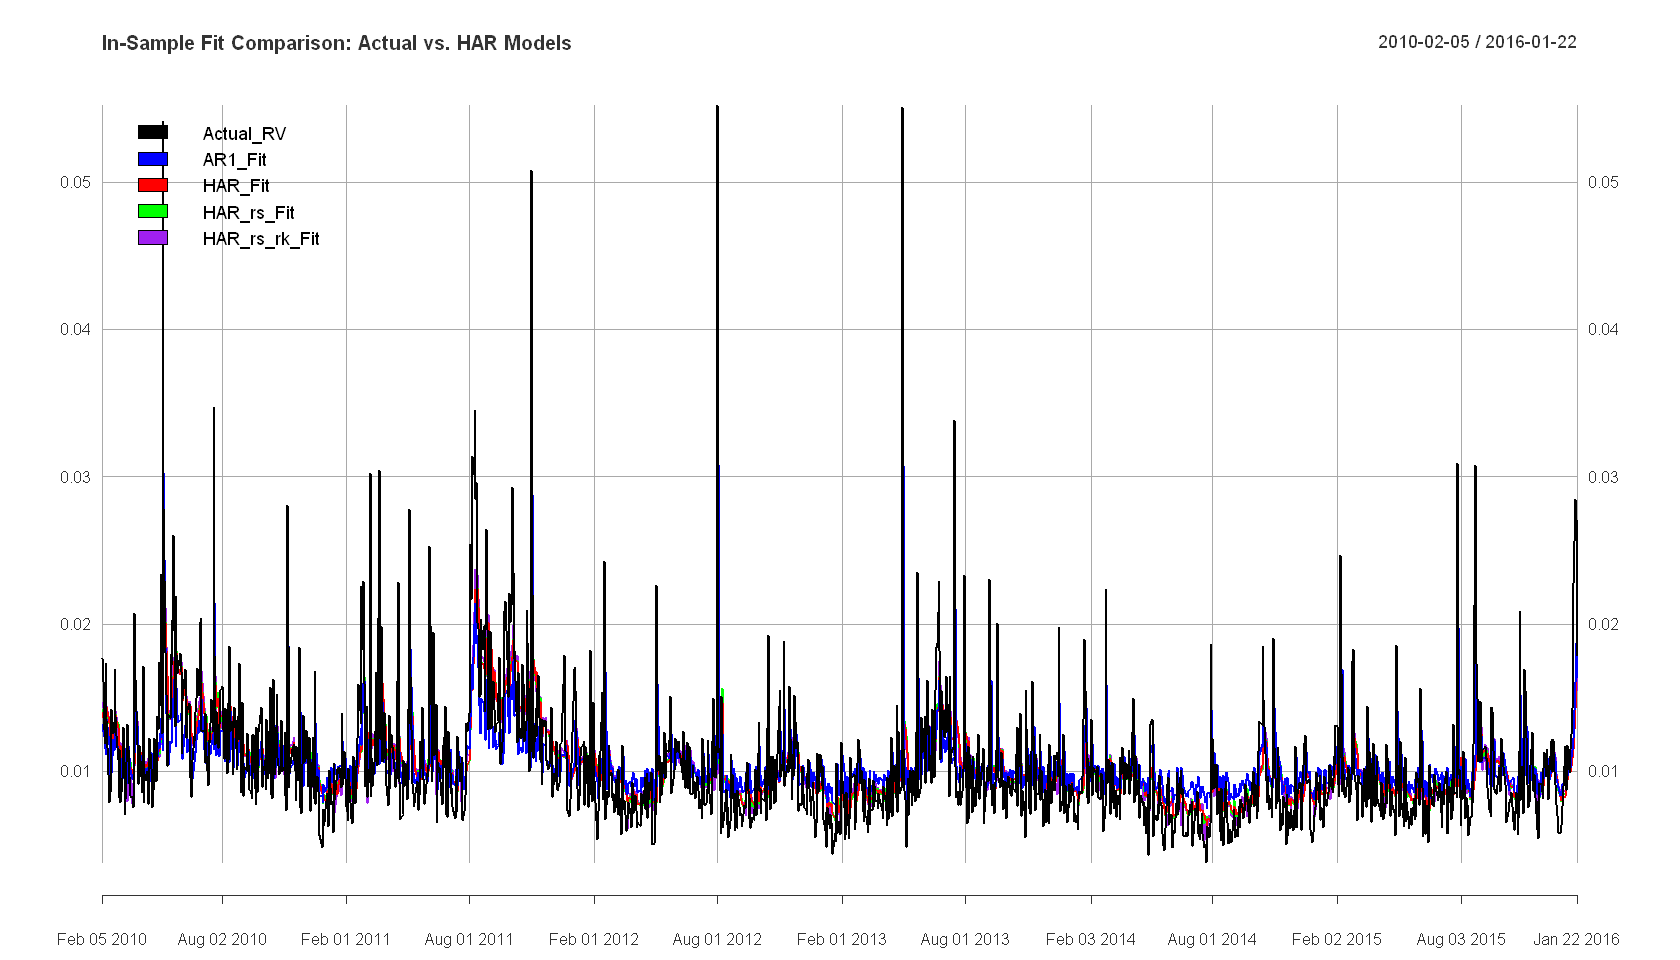

In [18]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "blue", "red", "green", "purple"),
         main = "In-Sample Fit Comparison: Actual vs. HAR Models",
         legend.loc = "topleft")

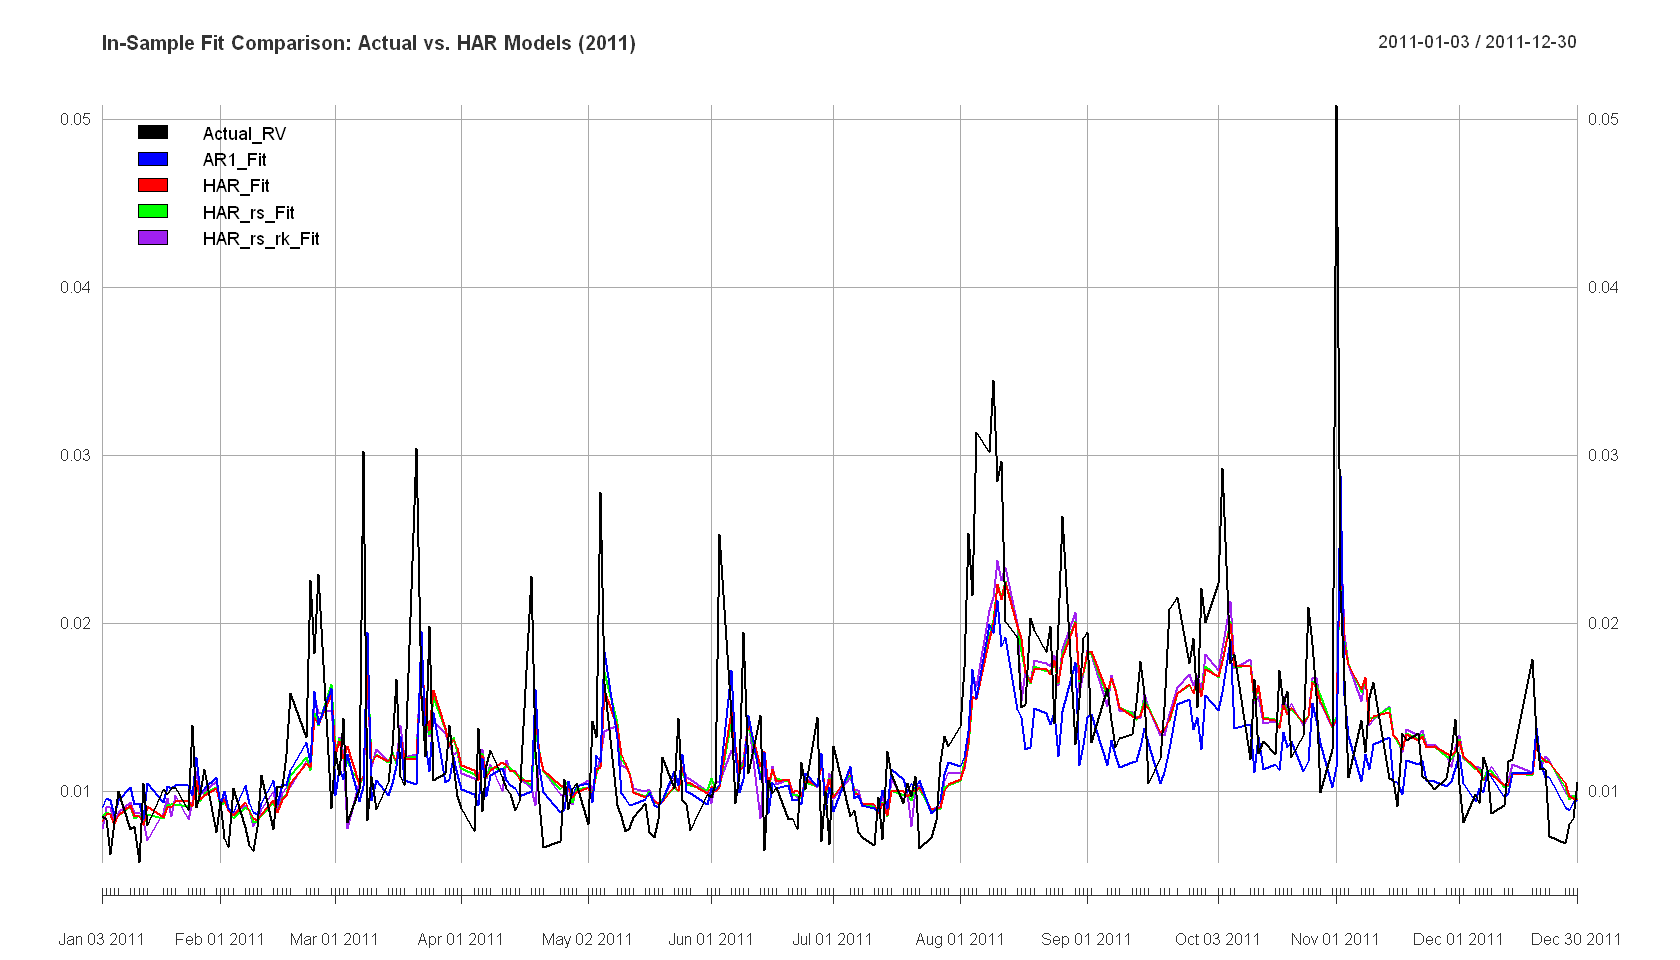

In [19]:
options(repr.plot.width = 14, repr.plot.height = 8)

#zoom in on 2011 for example
plot.xts(na.omit(fit_comparison["2011", c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, 
         col = c("black", "blue", "red", "green", "purple"),
         main = "In-Sample Fit Comparison: Actual vs. HAR Models (2011)",
         legend.loc = "topleft")

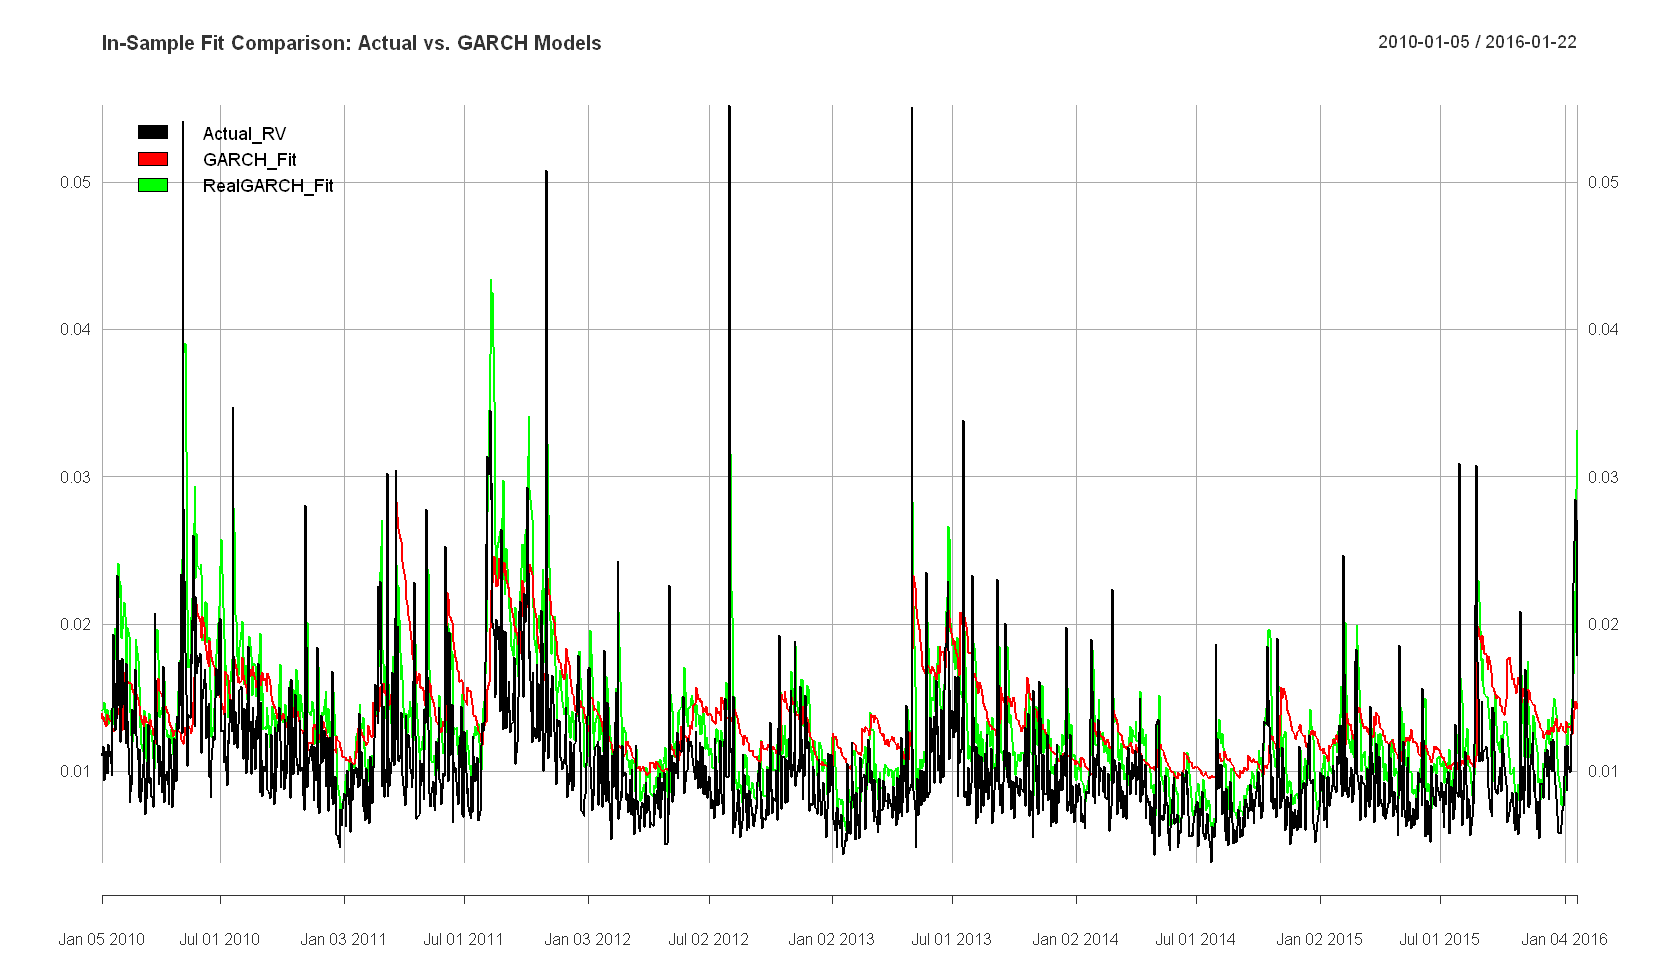

In [20]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "GARCH_Fit", "RealGARCH_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "red", "green"),
         main = "In-Sample Fit Comparison: Actual vs. GARCH Models",
         legend.loc = "topleft")

## Forectasts

In [21]:
window_len <- 750
n_obs <- nrow(har_data)
out_sample_len <- n_obs - window_len

In [22]:
fcst_ar1_roll <- numeric(out_sample_len)
fcst_har_roll <- numeric(out_sample_len)
fcst_har_rs_roll <- numeric(out_sample_len)
fcst_har_rs_rk_roll <- numeric(out_sample_len)

fcst_ar1_exp <- numeric(out_sample_len)
fcst_har_exp <- numeric(out_sample_len)
fcst_har_rs_exp <- numeric(out_sample_len)
fcst_har_rs_rk_exp <- numeric(out_sample_len)

# Actual values for the out-of-sample period to compare against
actual_out_sample <- har_data$RV[(window_len + 1):n_obs]

In [23]:
for (i in 1:out_sample_len) {
  
  # Rolling Window 
  train_data_roll <- har_data[i:(window_len + i - 1), ]
  
  # Expanding Window 
  train_data_exp <- har_data[1:(window_len + i - 1), ]
  
  # The row of data we are using to predict tomorrow's RV
  test_data <- har_data[(window_len + i), ]
  
  # --- ROLLING WINDOW FITS & FORECASTS ---
  fit_ar1_roll <- lm(RV ~ RV_1, data = train_data_roll)
  fit_har_roll <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_roll)
  fit_har_rs_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_roll)
  fit_har_rs_rk_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_roll)
    
  fcst_ar1_roll[i] <- predict(fit_ar1_roll, newdata = test_data)
  fcst_har_roll[i] <- predict(fit_har_roll, newdata = test_data)
  fcst_har_rs_roll[i] <- predict(fit_har_rs_roll, newdata = test_data)  
  fcst_har_rs_rk_roll[i] <- predict(fit_har_rs_rk_roll, newdata = test_data) 
    
  # --- EXPANDING WINDOW FITS & FORECASTS ---
  fit_ar1_exp <- lm(RV ~ RV_1, data = train_data_exp)
  fit_har_exp <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_exp)
  fit_har_rs_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_exp)
  fit_har_rs_rk_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_exp)
    
  fcst_ar1_exp[i] <- predict(fit_ar1_exp, newdata = test_data)
  fcst_har_exp[i] <- predict(fit_har_exp, newdata = test_data)
  fcst_har_rs_exp[i] <- predict(fit_har_rs_exp, newdata = test_data)  
  fcst_har_rs_rk_exp[i] <- predict(fit_har_rs_rk_exp, newdata = test_data)   
}

to dalsi nefunguje

In [ ]:
#garch_roll <- ugarchroll(spec_garch, data = asset_data$ret, 
#                         n.start = window_len, refit.every = 1, refit.window = "moving")
#garch_exp  <- ugarchroll(spec_garch, data = asset_data$ret, 
#                         n.start = window_len, refit.every = 1, refit.window = "recursive")
#
#fcst_garch_roll <- garch_roll@forecast$density[,"Sigma"]
#fcst_garch_exp  <- garch_exp@forecast$density[,"Sigma"]
#
# Realized GARCH (passing the realizedVol argument), REFIT 5 or 1? recalculate for every day or week? mostly bcs of computation
#realGARCH_roll <- ugarchroll(spec_real, data = asset_data$ret, realizedVol = asset_data$RV,
#                             n.start = window_len, refit.every = 5, refit.window = "moving", solver = "hybrid")
#realGARCH_exp  <- ugarchroll(spec_real, data = asset_data$ret, realizedVol = asset_data$RV,
#                             n.start = window_len, refit.every = 5, refit.window = "recursive", solver = "hybrid")
#
#fcst_realGARCH_roll <- realGARCH_roll@forecast$density[,"Sigma"]
#fcst_realGARCH_exp  <- realGARCH_exp@forecast$density[,"Sigma"]

In [24]:
# Helper function to calculate MSE and MAE
calc_loss <- function(actual, forecast) {
  error <- actual - forecast
  mse <- mean(error^2, na.rm = TRUE)
  mae <- mean(abs(error), na.rm = TRUE)
  return(c(MSE = mse, MAE = mae))
}

In [27]:
results_matrix <- rbind(
  calc_loss(actual_out_sample, fcst_ar1_roll),
  calc_loss(actual_out_sample, fcst_har_roll),
  calc_loss(actual_out_sample, fcst_har_rs_roll),
  calc_loss(actual_out_sample, fcst_har_rs_rk_roll),
  calc_loss(actual_out_sample, fcst_ar1_exp),
  calc_loss(actual_out_sample, fcst_har_exp),
  calc_loss(actual_out_sample, fcst_har_rs_exp),
  calc_loss(actual_out_sample, fcst_har_rs_rk_exp)
)

rownames(results_matrix) <- c(
  "AR1 (Roll)", "HAR (Roll)", "HAR-RS (Roll)", "HAR-RS-RK (Roll)",
  "AR1 (Exp)", "HAR (Exp)", "HAR-RS (Exp)", "HAR-RS-RK (Exp)"
)

In [28]:
cat("--- OUT-OF-SAMPLE FORECAST EVALUATION ---\n")
print(round(results_matrix, 7))

--- OUT-OF-SAMPLE FORECAST EVALUATION ---
                      MSE       MAE
AR1 (Roll)       1.36e-05 0.0022818
HAR (Roll)       1.29e-05 0.0021347
HAR-RS (Roll)    1.29e-05 0.0021288
HAR-RS-RK (Roll) 1.28e-05 0.0021174
AR1 (Exp)        1.39e-05 0.0024097
HAR (Exp)        1.28e-05 0.0021482
HAR-RS (Exp)     1.28e-05 0.0021468
HAR-RS-RK (Exp)  1.27e-05 0.0021336


In [29]:
err_ar1       <- actual_out_sample - fcst_ar1_roll
err_har       <- actual_out_sample - fcst_har_roll
err_har_rs    <- actual_out_sample - fcst_har_rs_roll
err_har_rs_rk <- actual_out_sample - fcst_har_rs_rk_roll

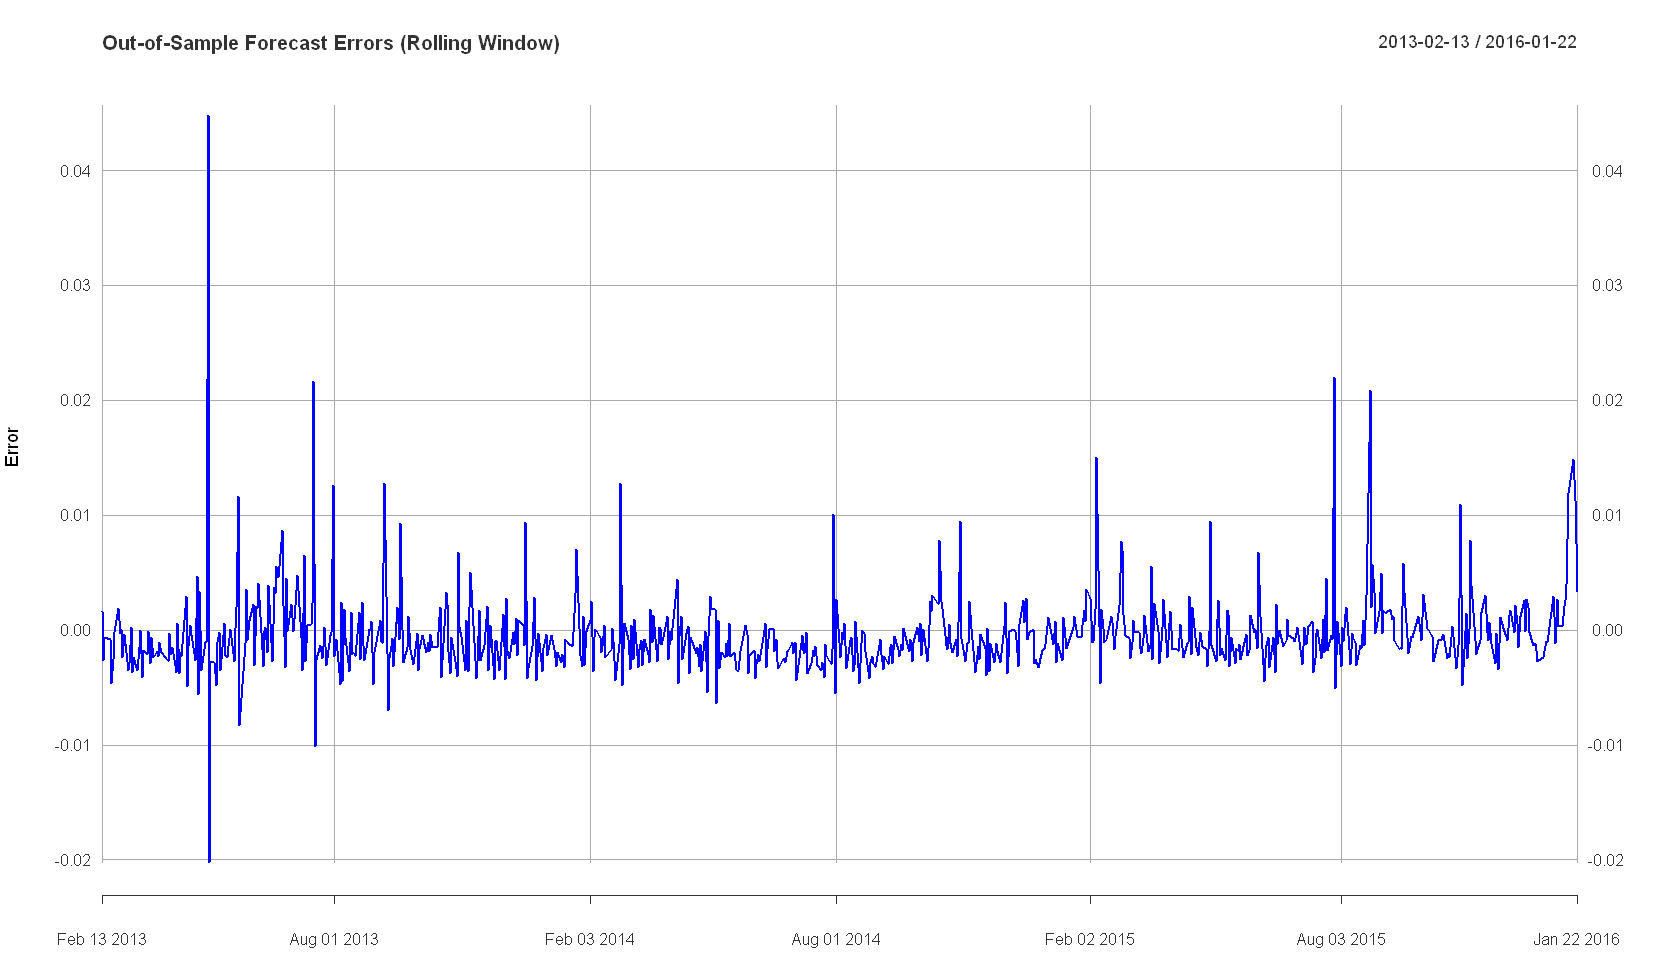

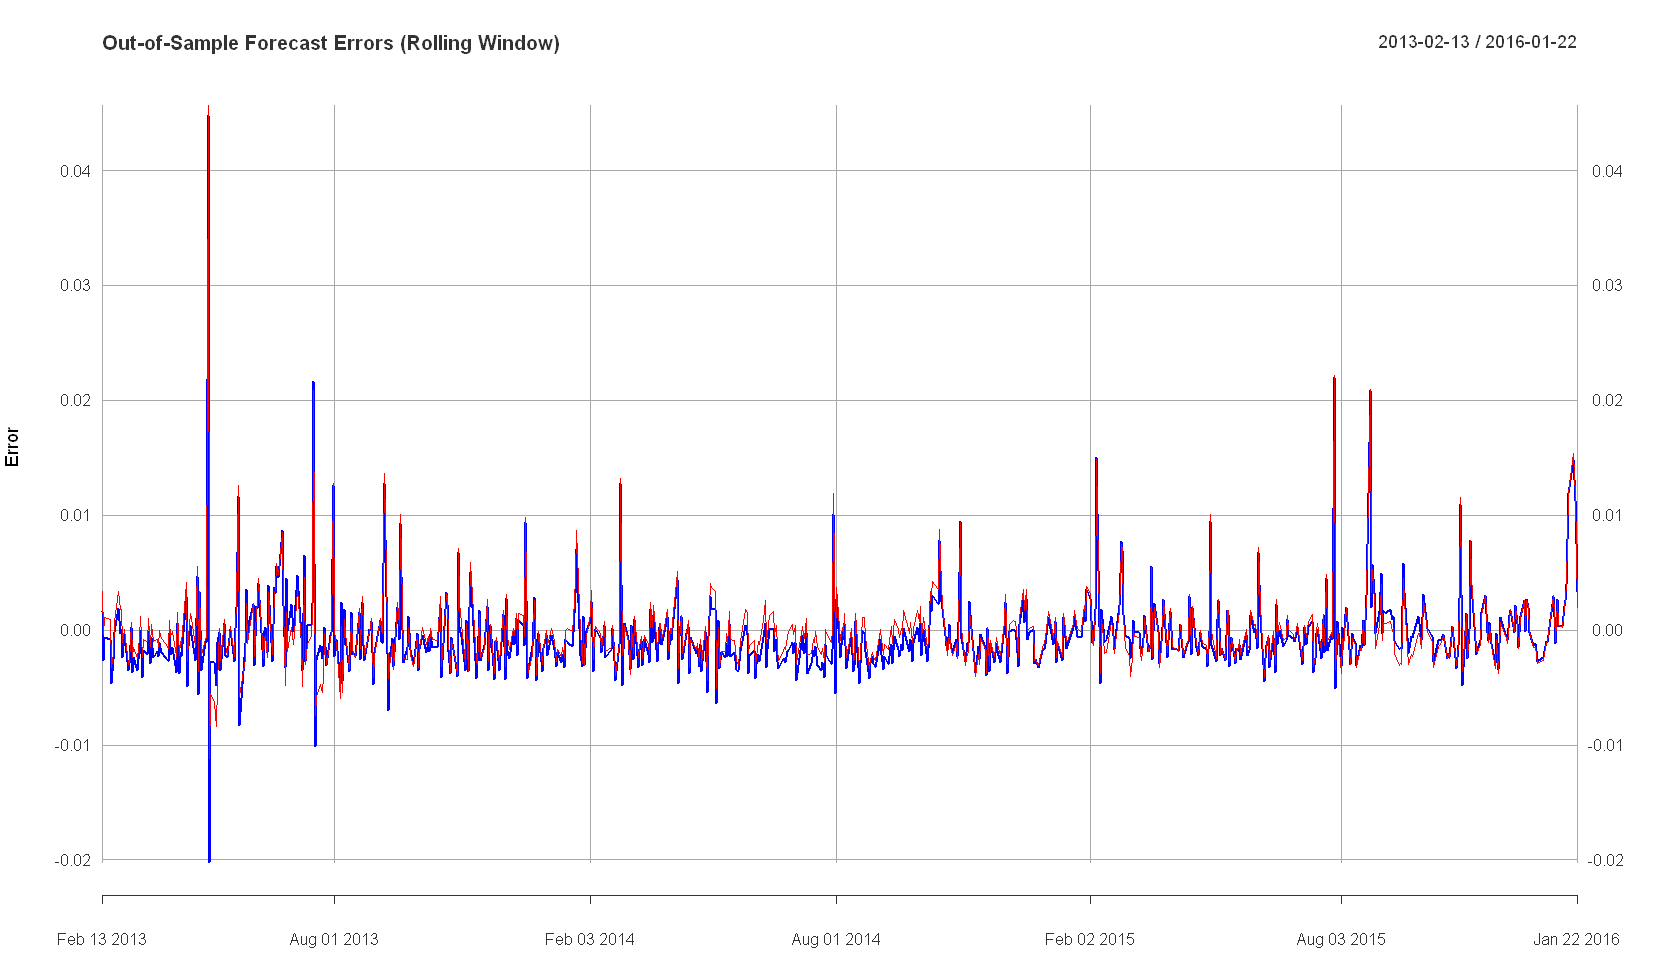

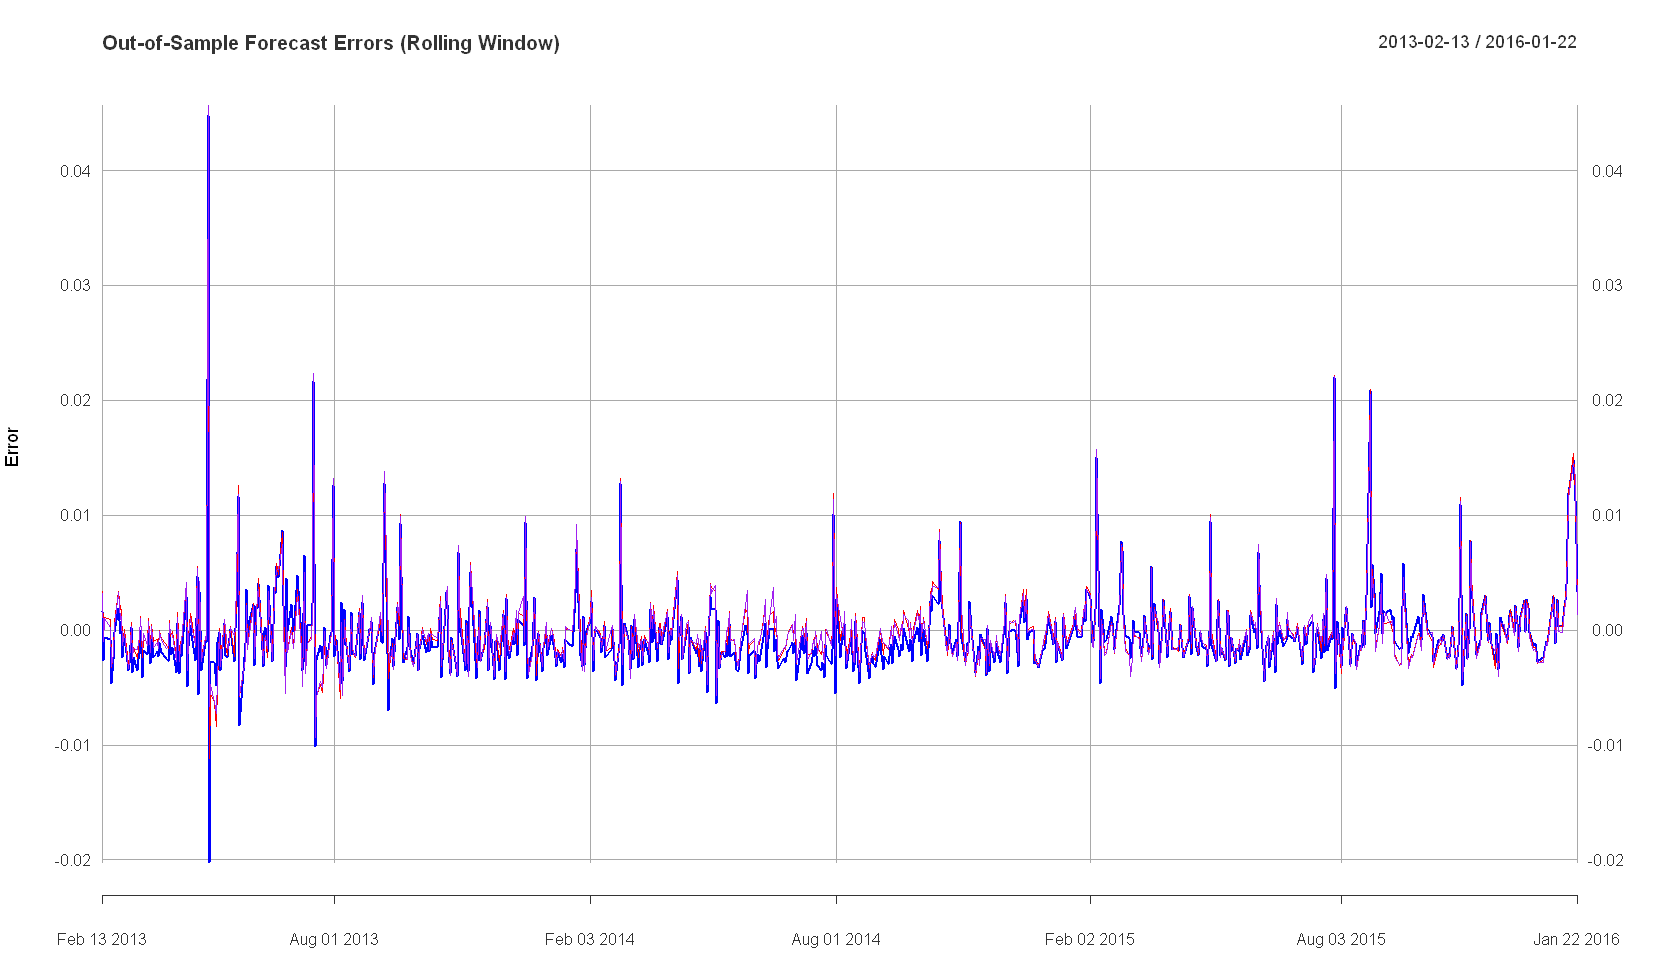

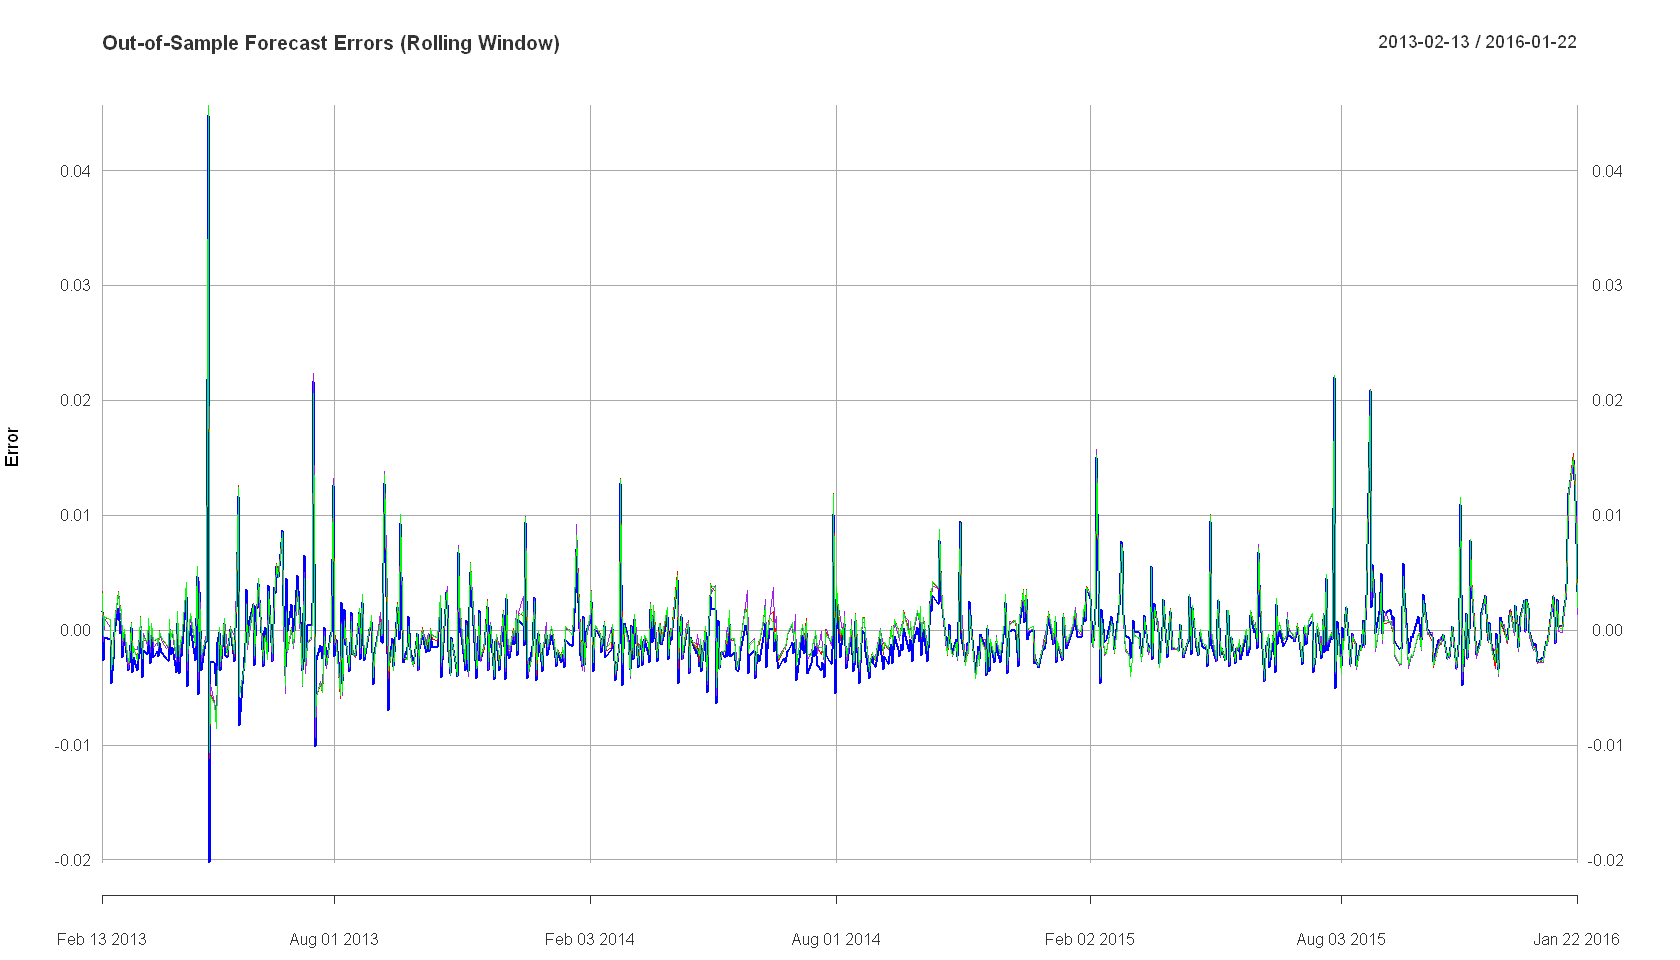

In [31]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot(err_ar1, type = "l", col = "blue", ylim = range(c(err_ar1, err_har), na.rm=TRUE),
     main = "Out-of-Sample Forecast Errors (Rolling Window)", ylab = "Error", xlab = "Time")
lines(err_har, col = "red")
lines(err_har_rs_rk, col = "purple")
lines(err_har_rs, col = "green")
legend("topleft", legend = c("AR1", "HAR", "HAR-RS-RK", "HAR-RS"), 
       col = c("blue", "red", "purple", "green"), lty = 1)

In [32]:
# 1. Diebold-Mariano Test (Comparing models against the baseline HAR model)
cat("\n--- DIEBOLD-MARIANO TESTS (vs HAR Rolling) ---\n")
print(dm.test(err_har, err_ar1, alternative = "two.sided", power = 2))
print(dm.test(err_har, err_har_rs_rk, alternative = "two.sided", power = 2))
print(dm.test(err_har, err_har_rs, alternative = "two.sided", power = 2))


--- DIEBOLD-MARIANO TESTS (vs HAR Rolling) ---

	Diebold-Mariano Test

data:  err_harerr_ar1
DM = -1.492, Forecast horizon = 1, Loss function power = 2, p-value =
0.1361
alternative hypothesis: two.sided


	Diebold-Mariano Test

data:  err_harerr_har_rs_rk
DM = 0.53994, Forecast horizon = 1, Loss function power = 2, p-value =
0.5894
alternative hypothesis: two.sided


	Diebold-Mariano Test

data:  err_harerr_har_rs
DM = 1.1282, Forecast horizon = 1, Loss function power = 2, p-value =
0.2596
alternative hypothesis: two.sided

